Task 2: Customer Segmentation Using Clustering

Problem Statement: Perform customer segmentation using unsupervised machine learning techniques to group mall customers based on their annual income and spending behavior.

In [1]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")  # use your filename exactly
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


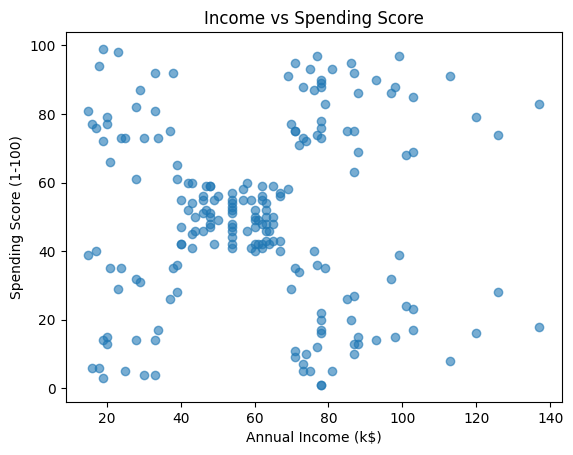

In [4]:
import matplotlib.pyplot as plt

plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], alpha=0.6)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Income vs Spending Score")
plt.show()

In [5]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

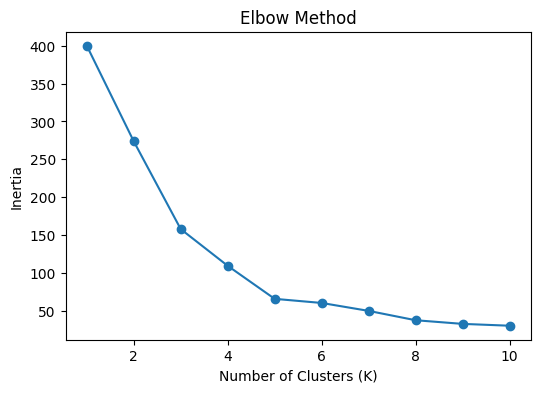

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


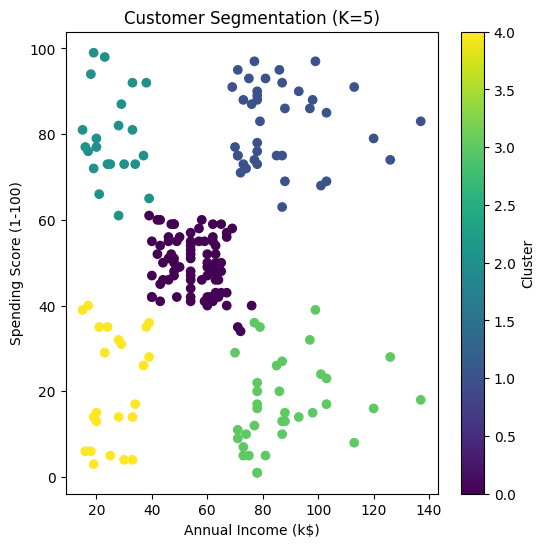

In [8]:
plt.figure(figsize=(6,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation (K=5)")
plt.colorbar(label="Cluster")
plt.show()

In [9]:
df.groupby("Cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


DBSCAN

In [10]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.35, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_labels

df["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
 3    88
 4    31
-1    23
 5    23
 0    16
 1    12
 2     7
Name: count, dtype: int64

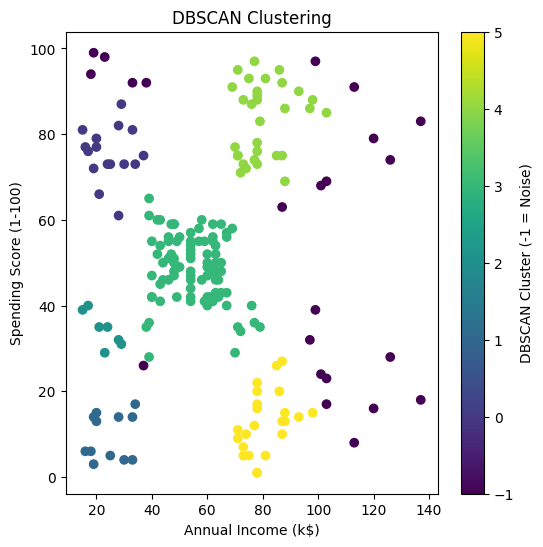

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["DBSCAN_Cluster"],
    cmap="viridis"
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clustering")
plt.colorbar(label="DBSCAN Cluster (-1 = Noise)")
plt.show()

In [12]:
print("KMeans cluster counts:")
print(df["Cluster"].value_counts().sort_index())

print("\nDBSCAN cluster counts (note -1 = noise):")
print(df["DBSCAN_Cluster"].value_counts().sort_index())

KMeans cluster counts:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

DBSCAN cluster counts (note -1 = noise):
DBSCAN_Cluster
-1    23
 0    16
 1    12
 2     7
 3    88
 4    31
 5    23
Name: count, dtype: int64


In [13]:
df.groupby("DBSCAN_Cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()

,Annual Income (k$),Spending Score (1-100)
DBSCAN_Cluster,,
-1,89.260870,57.826087
0,24.750000,75.375000
1,24.583333,9.583333
2,22.428571,34.428571
3,55.227273,48.579545
4,80.290323,83.193548
5,80.956522,12.782609


DBSCAN identified 6 dense customer clusters and labeled 23 customers as noise. Unlike K-Means, DBSCAN does not require specifying the number of clusters in advance and can automatically detect outliers. This highlights irregular customer behavior that K-Means would otherwise force into predefined clusters.

In [14]:
for eps in [0.2, 0.25, 0.3, 0.35, 0.4, 0.5]:
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).mean() * 100
    print(f"eps={eps}: clusters={n_clusters}, noise={noise_pct:.1f}%")

eps=0.2: clusters=7, noise=38.5%
eps=0.25: clusters=6, noise=25.0%
eps=0.3: clusters=7, noise=17.5%
eps=0.35: clusters=6, noise=11.5%
eps=0.4: clusters=4, noise=7.5%
eps=0.5: clusters=2, noise=4.0%
